In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


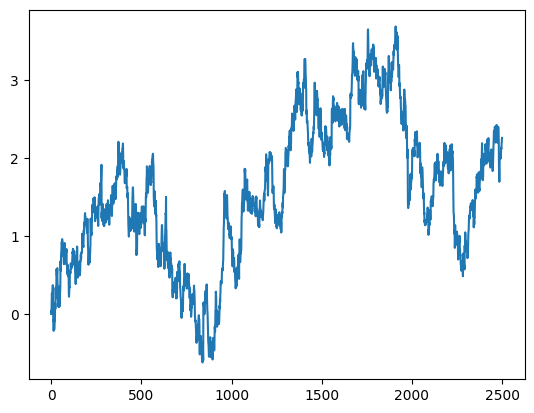

In [2]:
n = 10*250
T = 10
np.random.seed(12)
Z = np.random.standard_t(df=4,size=n)
X = np.zeros(shape=n+1)
X[0] = 0
delta_t = T/n
for i in range(1,n+1):
    X[i] = X[i-1]+np.sqrt(delta_t)*Z[i-1]

plt.plot(X)
plt.show()

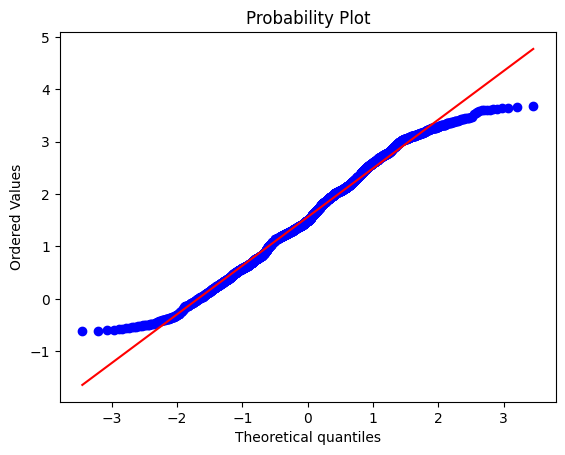

In [3]:
import matplotlib.pyplot as plt


stats.probplot(X, dist="norm", plot=plt)
plt.show()

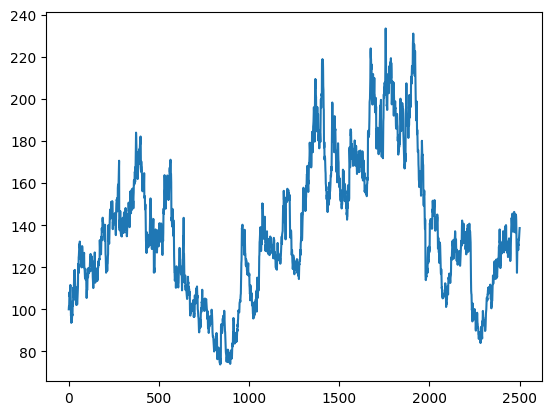

In [4]:
sigma = 0.3; r = 0.01
t = np.linspace(0,T,num=n+1)
Y = 100*np.exp((r-sigma**2/2)*t+sigma*X)
plt.plot(Y)
plt.show()

In [5]:
print(Y.shape)
print(Y[0])

(2501,)
100.0


In [6]:
log_returns = np.diff(np.log(Y))

window = 30
mean = []
vol = []
vol_t = []

for start in range(0, len(log_returns) - window + 1, window):
    block = log_returns[start:start+window]
    vol.append(np.std(block, ddof=1))
    mean.append(np.mean(block))
    vol_t.append(t[start + window])

vol = np.array(vol)
mean=np.array(mean)
vol_t = np.array(vol_t)

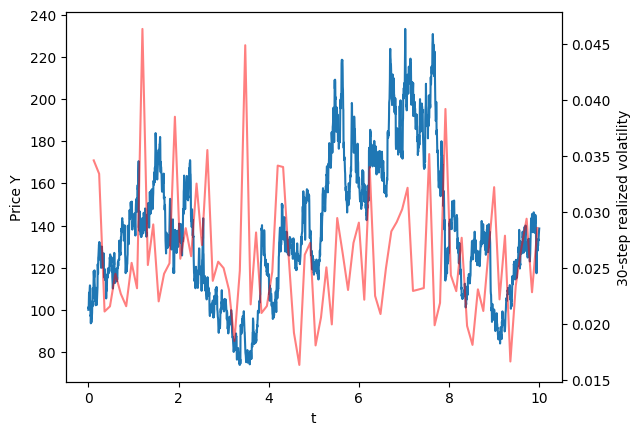

In [7]:
fig, ax1 = plt.subplots()

ax1.plot(t, Y)
ax1.set_xlabel("t")
ax1.set_ylabel("Price Y")

ax2 = ax1.twinx()
ax2.plot(vol_t, vol,color="red",alpha=0.5)

ax2.set_ylabel(f"{window}-step realized volatility")

plt.show()